In [2]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Here, based on investigations done in `FragmentingCollisions_Diagnostics.ipynb` I isolate a single collision and start the simulation from before the collision, saving a simulationArchive every time step. You can find the error spikes in that specific collision in the mentioned notebook.

This specific example is for `embryo_ias15_8` run. 

# Big file first

The t we're looking at here is t = 303089.6

In [3]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [4]:
ias15_famtree = pd.read_csv(
    "../examples/embryo_ias15/famtree_8_ias15.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [5]:
coll_1 = ias15_famtree[(ias15_famtree['parent1_id'] == 69) & ((ias15_famtree['parent2_id'] == 75))]
coll_1.head()

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
31,303089.6,6,80,69,75,1.400000e-08,3.033543e-07,1.261327e-07,0.000009,0.000024,0.000018,5.247393,0.196125
32,303089.6,6,81,69,75,9.020025e-09,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
33,303089.6,6,82,69,75,8.668006e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
34,303089.6,6,83,69,75,7.840046e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
35,303089.6,6,84,69,75,7.600544e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125


In [6]:
t1 = coll_1['t'].iloc[0]
print("t_1 = ", t1)

t_1 =  303089.6


In [7]:
ias15_archive = rebound.Simulationarchive("../examples/embryo_ias15/embryo_ias15_8")

ias15_times = []
ias15_n_bodies = []
ias15_masses = []
ias15_mass_errors = []
ias15_angular_momentums = []
ias15_L_rel_errors = []
ias15_es = []
ias15_rel_e_errors = []

for i in range(len(ias15_archive)):
    snap = ias15_archive[i]
    ias15_times.append(snap.t)
    ias15_n_bodies.append(snap.N)
    ias15_es.append(snap.energy())

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_angular_momentums.append(get_abs(Lx, Ly, Lz))

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_masses.append(m)

for i in range(len(ias15_masses)):
    diff = np.abs((ias15_masses[i] - ias15_masses[0]))
    rel_diff = diff/np.abs(ias15_masses[0])
    ias15_mass_errors.append(rel_diff)

for i in range(len(ias15_es)):
    diff = np.abs((ias15_es[i] - ias15_es[0]))
    rel_diff = diff/np.abs(ias15_es[0])
    ias15_rel_e_errors.append(rel_diff)

for i in range(len(ias15_angular_momentums)):
    diff = np.abs(ias15_angular_momentums[i] - ias15_angular_momentums[0])
    ias15_L_rel_errors.append(diff/np.abs(ias15_angular_momentums[0]))

    ias15_dict = {
    't': ias15_times,
    'N_Bodies': ias15_n_bodies,
    'total_masses': ias15_masses,
    'm_errors': ias15_mass_errors,
    'angular_momentums': ias15_angular_momentums,
    'L_rel_errors': ias15_L_rel_errors,
    'E_rel_errors': ias15_rel_e_errors
}

ias15_archive_df = pd.DataFrame(ias15_dict)

ias15_archive_df.head()

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E_rel_errors
0,0.000000,31,1.000009,0.0,0.00003,0.000000e+00,0.000000e+00
1,10.000459,31,1.000009,0.0,0.00003,3.440551e-16,2.738603e-16
2,20.000112,31,1.000009,0.0,0.00003,1.146850e-16,3.560184e-15
3,30.000448,31,1.000009,0.0,0.00003,1.146850e-16,3.697114e-15
4,40.000266,31,1.000009,0.0,0.00003,1.146850e-16,3.012464e-15


In [8]:
t1 = 303089.6

Text(0.5, 0.98, 'TRACE and IAS15, run 8')

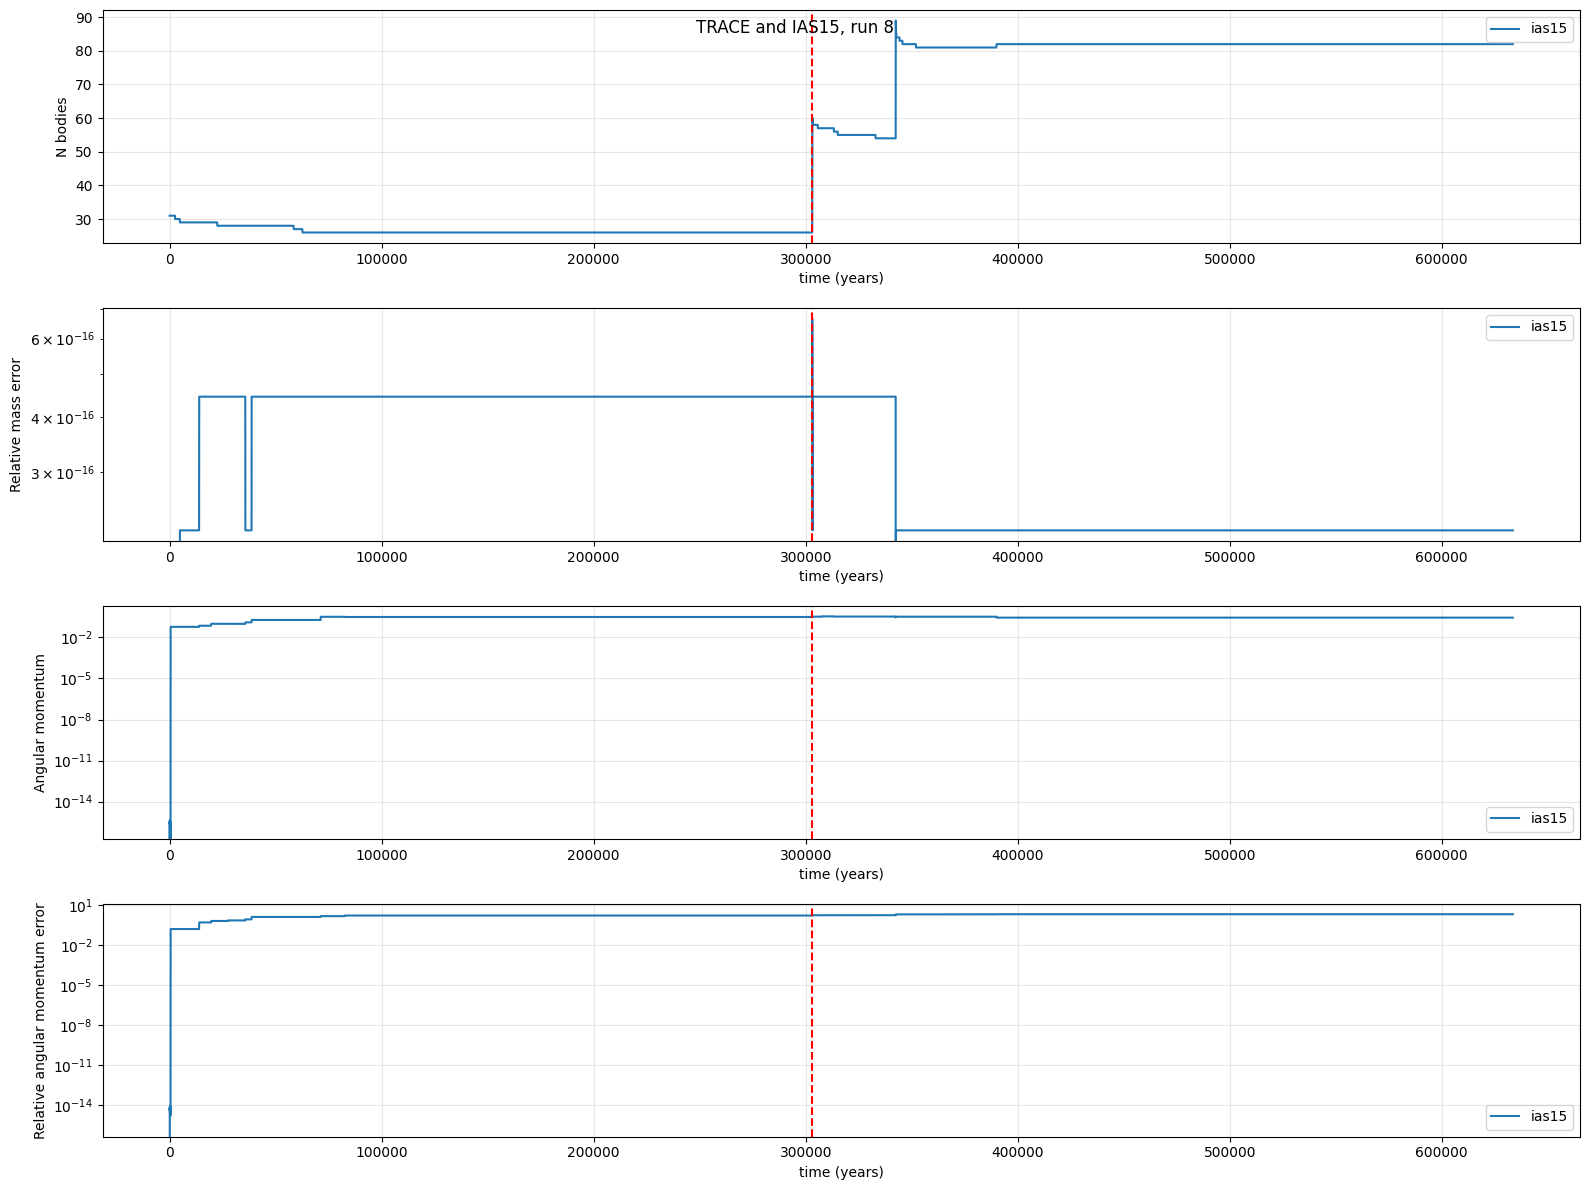

In [9]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(ias15_archive_df['t'], ias15_archive_df['N_Bodies'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

plt.subplot(4, 1, 2)
plt.plot(ias15_archive_df['t'], ias15_archive_df['m_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')


plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

plt.subplot(4, 1, 3)
plt.plot(ias15_archive_df['t'], ias15_archive_df['L_rel_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

plt.subplot(4, 1, 4)
plt.plot(ias15_archive_df['t'], ias15_archive_df['E_rel_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")


plt.tight_layout()

plt.suptitle("TRACE and IAS15, run 8")

# Detailed archive (timestep by timestep)

In [10]:
ias15_8_det_archive = rebound.Simulationarchive("../examples/embryo_ias15_8/archive_ias15_det.bin")

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)


In [11]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [12]:
ias15_det_times = []
ias15_det_n_bodies = []
ias15_det_masses = []
ias15_det_mass_errors = []
ias15_det_angular_momentums = []
ias15_det_L_rel_errors = []
ias15_det_Es = []
ias15_det_E_rel_errors = []
snapshot_idxs = []

for i in range(len(ias15_8_det_archive)):
    snap = ias15_8_det_archive[i]
    snapshot_idxs.append(i)
    ias15_det_times.append(snap.t)
    ias15_det_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_det_angular_momentums.append(get_abs(Lx, Ly, Lz))
    ias15_det_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_det_masses.append(m)

for i in range(len(ias15_det_masses)):
    diff = np.abs((ias15_det_masses[i] - ias15_det_masses[0]))
    rel_diff = diff/np.abs(ias15_det_masses[0])
    ias15_det_mass_errors.append(rel_diff)

for i in range(len(ias15_det_angular_momentums)):
    diff = np.abs(ias15_det_angular_momentums[i] - ias15_det_angular_momentums[0])
    ias15_det_L_rel_errors.append(diff/np.abs(ias15_det_angular_momentums[0]))

for i in range(len(ias15_det_Es)):
    diff = np.abs(ias15_det_Es[i] - ias15_det_Es[0])
    ias15_det_E_rel_errors.append(diff/np.abs(ias15_det_Es[0]))


ias15_det_dict = {
    't': ias15_det_times,
    'N_Bodies': ias15_det_n_bodies,
    'total_masses': ias15_det_masses,
    'm_errors': ias15_det_mass_errors,
    'angular_momentums': ias15_det_angular_momentums,
    'L_rel_errors': ias15_det_L_rel_errors,
    'E': ias15_det_Es,
    'E_rel_errors': ias15_det_E_rel_errors,
    'snapshot_idx': snapshot_idxs
}

ias15_det_archive_df = pd.DataFrame(ias15_det_dict)

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [13]:
ias15_famtree_det = pd.read_csv(
    "../examples/embryo_ias15_8/famtree_8.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

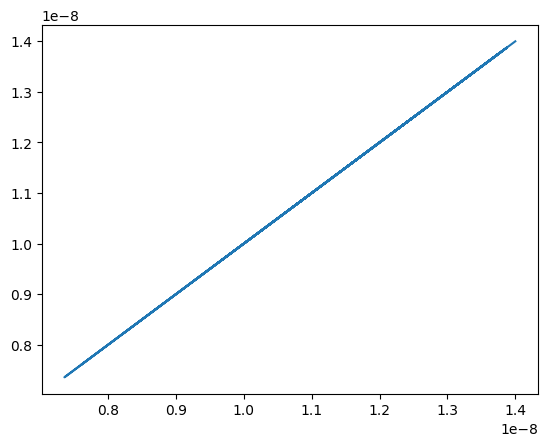

In [17]:
plt.plot(coll_1['new_mass'], ias15_famtree_det['new_mass'])

In [16]:
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
31,303089.6,6,80,69,75,1.400000e-08,3.033543e-07,1.261327e-07,0.000009,0.000024,0.000018,5.247393,0.196125
32,303089.6,6,81,69,75,9.020025e-09,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
33,303089.6,6,82,69,75,8.668006e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
34,303089.6,6,83,69,75,7.840046e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
35,303089.6,6,84,69,75,7.600544e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
36,303089.6,6,85,69,75,1.091575e-08,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
37,303089.6,6,86,69,75,1.387637e-08,3.033543e-07,1.261327e-07,0.000009,0.000024,0.000018,5.247393,0.196125
38,303089.6,6,87,69,75,1.244204e-08,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
39,303089.6,6,88,69,75,1.172087e-08,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
40,303089.6,6,89,69,75,8.225870e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125


In [14]:
ias15_famtree_det

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,303089.6,6,26,4,10,1.400000e-08,3.033543e-07,1.261327e-07,0.000009,0.000024,0.000018,5.247393,0.196125
1,303089.6,6,27,4,10,9.020025e-09,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
2,303089.6,6,28,4,10,8.668006e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
3,303089.6,6,29,4,10,7.840046e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
4,303089.6,6,30,4,10,7.600544e-09,3.033543e-07,1.261327e-07,0.000007,0.000024,0.000018,5.247393,0.196125
5,303089.6,6,31,4,10,1.091575e-08,3.033543e-07,1.261327e-07,0.000008,0.000024,0.000018,5.247393,0.196125
6,303089.6,6,32,4,10,1.387637e-08,3.033543e-07,1.261327e-07,NaN,0.000024,0.000018,5.247393,0.196125
7,303089.6,6,33,4,10,1.244204e-08,3.033543e-07,1.261327e-07,NaN,0.000024,0.000018,5.247393,0.196125
8,303089.6,6,34,4,10,1.172087e-08,3.033543e-07,1.261327e-07,NaN,0.000024,0.000018,5.247393,0.196125
9,303089.6,6,35,4,10,8.225870e-09,3.033543e-07,1.261327e-07,NaN,0.000024,0.000018,5.247393,0.196125


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_46609/1573872603.py:21: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


Text(0.5, 0.98, 'TRACE and IAS15, run 8')

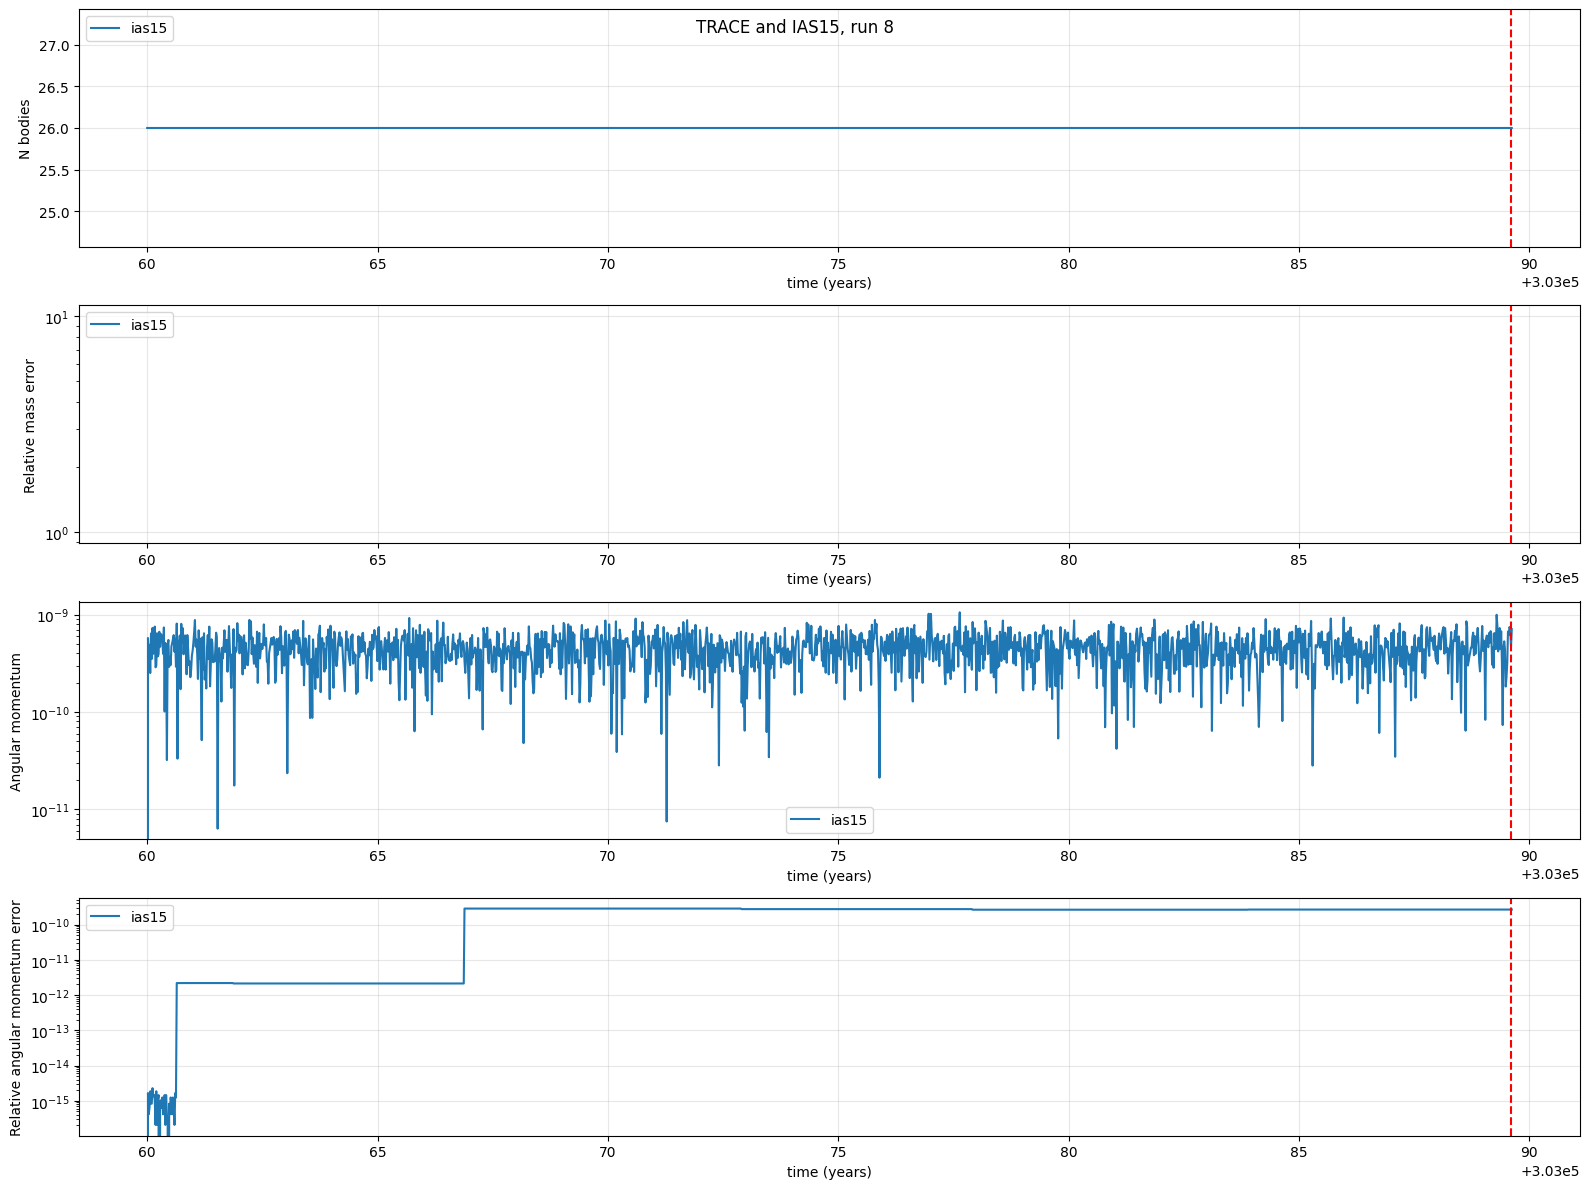

In [40]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(ias15_det_archive_df['t'], ias15_det_archive_df['N_Bodies'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

plt.subplot(4, 1, 2)
plt.plot(ias15_det_archive_df['t'], ias15_det_archive_df['m_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')


plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

plt.subplot(4, 1, 3)
plt.plot(ias15_det_archive_df['t'], ias15_det_archive_df['L_rel_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

plt.subplot(4, 1, 4)
plt.plot(ias15_det_archive_df['t'], ias15_det_archive_df['E_rel_errors'], label = 'ias15')
plt.axvline(t1, color = 'red', linestyle = '--')

plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")


plt.tight_layout()

plt.suptitle("TRACE and IAS15, run 8")

In [42]:
t1

303089.6

In [16]:
close_up = ias15_det_archive_df[(ias15_det_archive_df['t'] < t1 + 10) & (ias15_det_archive_df['t'] > t1 - 10)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
1193,303079.611604,26,1.000009,0.0,0.000039,4.214132e-10,0.000522,2.646216e-10,1193
1194,303079.627593,26,1.000009,0.0,0.000039,6.828973e-10,0.000522,2.646214e-10,1194
1195,303079.644705,26,1.000009,0.0,0.000039,1.361971e-10,0.000522,2.646221e-10,1195
1196,303079.660396,26,1.000009,0.0,0.000039,5.338686e-10,0.000522,2.646221e-10,1196
1197,303079.677082,26,1.000009,0.0,0.000039,4.919866e-10,0.000522,2.646202e-10,1197
...,...,...,...,...,...,...,...,...,...
1798,303089.556500,26,1.000009,0.0,0.000039,6.176382e-10,0.000522,2.671253e-10,1798
1799,303089.572868,26,1.000009,0.0,0.000039,7.454023e-10,0.000522,2.671242e-10,1799
1800,303089.589666,26,1.000009,0.0,0.000039,7.042859e-10,0.000522,2.671226e-10,1800
1801,303089.605857,26,1.000009,0.0,0.000039,4.693505e-10,0.000522,2.671242e-10,1801


In [20]:
ias15_det_archive_df['N_Bodies'].unique()

array([26])

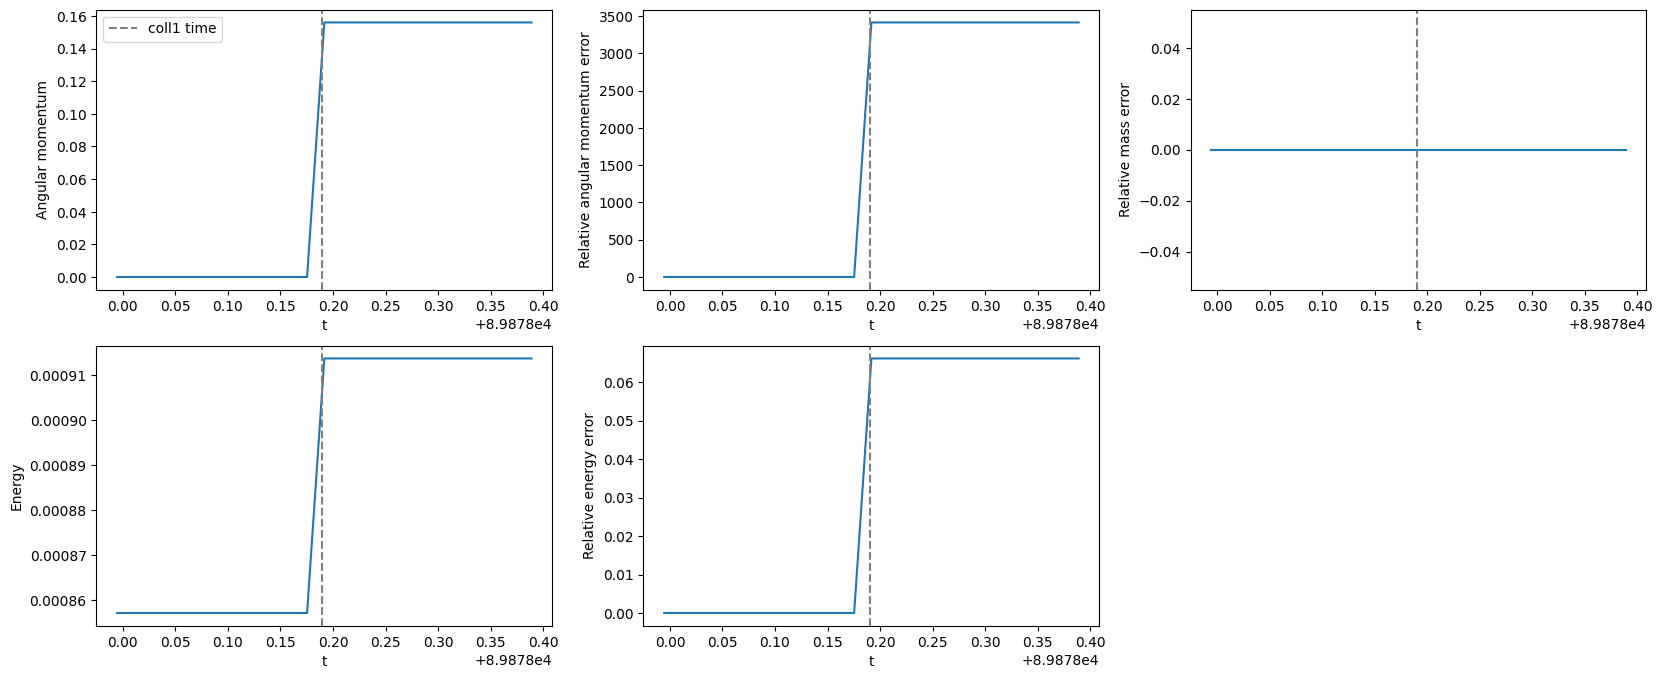

In [12]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

# Check velocities before and after collision: does the code give us what we expect?

In [ ]:
idx_before = 497
idx_after = 498

snap_before = ias15_8_det_archive[497]
snap_after = ias15_8_det_archive[498]

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [16]:
m_parent1 = coll_1['parent1_mass'].iloc[0]
m_parent2 = coll_1['parent2_mass'].iloc[0]
r_parent1 = coll_1['parent1_radius'].iloc[0]
r_parent2 = coll_1['parent2_radius'].iloc[0]

m_frag1 = coll_1['new_mass'].iloc[0]
m_frag2 = coll_1['new_mass'].iloc[1]
m_frag3 = coll_1['new_mass'].iloc[2]

In [20]:
for i in range(snap_before.N):
    particle = snap_before.particles[i]
    if np.isclose(particle.m, m_parent1, atol=1e-11):
        parent1_before = particle
        print("parent1 mass = ", particle.m)

    if np.isclose(particle.m, m_parent2, atol=1e-11):
        parent2_before = particle
        print("parent2 mass = ", particle.m)

parent1 mass =  3.610303517342687e-07
parent2 mass =  1.3439302235566334e-08


In [32]:
for i in range(snap_after.N):
    particle = snap_after.particles[i]
    if np.isclose(particle.m, m_frag1, atol=1e-11):
        frag1 = particle
        print("frag1 mass = ", particle.m)

    if np.isclose(particle.m, m_frag2, atol=1e-11):
        frag2 = particle
        print("frag2 mass = ", particle.m)

    if np.isclose(particle.m, m_frag3, atol=1e-11):
        frag3 = particle
        print("frag3 mass = ", particle.m)

lr_mass = np.max([frag1.m, frag2.m, frag3.m])
print("lr_mass = ", lr_mass)

# Since we can see by printing that lr is frag1, then we can save frag2 and 3 as small frags
small_frags = [frag2, frag3]

frag1 mass =  2.0336529597486478e-07
frag2 mass =  6.18299255821101e-08
frag3 mass =  1.0927443241286017e-07
lr_mass =  2.0336529597486478e-07


In [53]:
# 1. Determine Target and Projectile based on mass (Target is >= Projectile)
if parent1_before.m >= parent2_before.m:
    target = parent1_before
    projectile = parent2_before
else:
    target = parent2_before
    projectile = parent1_before

initial_mass = target.m + projectile.m

# 2. Setup initial vectors
v_target = np.array([target.vx, target.vy, target.vz])
v_proj = np.array([projectile.vx, projectile.vy, projectile.vz])
r_target = np.array([target.x, target.y, target.z])
r_proj = np.array([projectile.x, projectile.y, projectile.z])

v_com = (target.m * v_target + projectile.m * v_proj) / initial_mass

# 3. Calculate internal expansion velocity 
# Note: Replicating the frame-dependent logic currently in the C code
v_lr = np.linalg.norm(v_com)

# 4. Relative vectors & Collision Plane
dv = v_target - v_proj
dr = r_target - r_proj
unit_dv = dv / np.linalg.norm(dv)

normal_coll_plane = np.cross(dv, dr)
mag_ncp = np.linalg.norm(normal_coll_plane)
print(mag_ncp)

# Collinear fallback (replicating C code lines 241-250)
if mag_ncp < 1e-15:
    arb_vec = np.cross(unit_dv, np.array([1.0, 0.0, 0.0]))
    if np.linalg.norm(arb_vec) < 1e-15:
        arb_vec = np.cross(unit_dv, np.array([0.0, 1.0, 0.0]))
    normal_coll_plane = arb_vec
    mag_ncp = np.linalg.norm(normal_coll_plane)

normal_coll_plane = normal_coll_plane / mag_ncp
normal_to_vrel = np.cross(dv, normal_coll_plane)
normal_to_vrel = normal_to_vrel / np.linalg.norm(normal_to_vrel)

# 5. Map fragments 
n_frag = len(small_frags) + 1 
theta_sep = (2.0 * np.pi) / n_frag

# 6. Assign Initial Velocities and Track Momentum
mvsum = lr_mass * v_com 
target_v_raw = v_com 

frag_velocities_raw = []

for j, frag in enumerate(small_frags, start=1):
    frag_velocity_mag = v_lr * np.sqrt(lr_mass / frag.m)
    print("j = ", j)
    
    cos_t = np.cos(theta_sep * j)
    sin_t = np.sin(theta_sep * j)
    
    v_frag_raw = v_com + frag_velocity_mag * (cos_t * unit_dv + sin_t * normal_to_vrel)
    frag_velocities_raw.append({'mass': frag.m, 'v_raw': v_frag_raw})
    
    mvsum += frag.m * v_frag_raw

# 7. Momentum Offset Correction 
voff = v_com - (mvsum / initial_mass)

target_v_final = target_v_raw + voff * (lr_mass / initial_mass)
print(f"Largest Remnant Expected v: {target_v_final}, abs = {get_abs(target_v_final[0], target_v_final[1], target_v_final[2])}")

for j, frag_dict in enumerate(frag_velocities_raw):
    v_frag_final = frag_dict['v_raw'] + voff * (frag_dict['mass'] / initial_mass)
    print(f"Small Fragment {j+2} Expected v: {v_frag_final}, abs = {get_abs(v_frag_final[0], v_frag_final[1], v_frag_final[2])}")

0.7619370224983251
j =  1
j =  2
Largest Remnant Expected v: [-14.57913572  -3.04477395   0.42288846], abs = 14.899687286700845
Small Fragment 2 Expected v: [-26.2532582   17.90559654  -1.90725682], abs = 31.83522549146182
Small Fragment 3 Expected v: [ 3.85294665 -1.15696973  1.06710076], abs = 4.162028452330161


In [ ]:
print(f"parent1 vx = {parent1_before.vx}, vy = {parent1_before.vy}, vz = {parent1_before.vz}")
print(f"parent2 vx = {parent2_before.vx}, vy = {parent2_before.vy}, vz = {parent2_before.vz}")
print(f"frag1 vx = {frag1.vx}, vy = {frag1.vy}, vz = {frag1.vz}, |v| = {get_abs(frag1.vx, frag1.vy, frag1.vz)}")
print(f"frag2 vx = {frag2.vx}, vy = {frag2.vy}, vz = {frag2.vz}, |v| = {get_abs(frag2.vx, frag2.vy, frag2.vz)}")
print(f"frag3 vx = {frag3.vx}, vy = {frag3.vy}, vz = {frag3.vz}, |v| = {get_abs(frag3.vx, frag3.vy, frag3.vz)}")

parent1 vx = -13.137913776570347, vy = -1.5377356191382705, vz = 0.35527063169252837
parent2 vx = -7.313823415689315, vy = 9.899528702734766, vz = -0.38208003425935105
frag1 vx = -10.308483365367819, vy = -13.328199550293313, vz = 1.1969321721589077, |v| = 16.891961969269673
frag2 vx = 11.663882071321149, vy = 3.2170337212500795, vz = 0.7662686552799716, |v| = 12.123638834500625
frag3 vx = -32.40875433282525, vy = -25.105948735129633, vz = 1.492952753373554, |v| = 41.02273671051436


# Check n_frag

In [39]:
def reb_random_powerlaw(m_min, m_max, slope):
    """
    Generates a random mass from a power-law distribution P(m) ~ m^(-slope).
    """
    y = np.random.uniform(0, 1)
    
    # Handle the slope == 1 edge case (logarithmic) just in case, 
    # though your code hardcodes slope = 3.
    if np.isclose(slope, 1.0):
        return m_min * np.exp(y * np.log(m_max / m_min))
    else:
        a = 1.0 - slope
        return (y * (m_max**a - m_min**a) + m_min**a) ** (1.0 / a)


def get_fragment_masses(lr_mass, slr_mass, remaining_mass, min_frag_mass):
    """
    Calculates the distribution of fragment masses and returns the list of 
    fragment masses along with the total count (n_frag).
    """
    # 1. Determine maximum fragment mass
    if slr_mass > 0:
        max_frag_mass = 0.5 * slr_mass
    else:
        max_frag_mass = 0.5 * lr_mass

    powerlaw_slope = 3.0
    m_frags = []
    sum_m_frags = 0.0

    # 2. Draw until we reach above the remaining mass
    while sum_m_frags < remaining_mass and len(m_frags) < 10000:
        frag_m = reb_random_powerlaw(min_frag_mass, max_frag_mass, powerlaw_slope)
        m_frags.append(frag_m)
        sum_m_frags += frag_m

    # 3. Handle outcomes based on fragment count
    if len(m_frags) >= 10000:
        raise ValueError(
            "Number of fragments produced is above permitted value (10000). "
            "Increase minimum fragment mass."
        )
        
    elif len(m_frags) == 1:
        m_frags[0] = remaining_mass
        
    elif len(m_frags) > 1:
        # Discard the last fragment
        discarded_frag = m_frags.pop()
        sum_m_frags -= discarded_frag
        
        # Distribute the mass scaling ratio between the remaining fragments
        ratio = remaining_mass / sum_m_frags
        m_frags = [m * ratio for m in m_frags]

    n_frag = len(m_frags)
    
    return m_frags, n_frag

In [49]:
ms

[np.float64(3.970928919772191e-08),
 np.float64(7.139935930972416e-08),
 np.float64(5.999570948752414e-08)]